In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [38]:
def plot_binary_data(filename, n, m):
    """
    n x m の unsigned char バイナリファイルを読み込んで2次元描画する関数
    
    Parameters:
    filename (str): バイナリファイルのパス
    n (int): 行数 (縦の解像度 / Height)
    m (int): 列数 (横の解像度 / Width)
    """
    try:
        # 1. バイナリファイルからデータを読み込む (unsigned char = np.uint8)
        raw_data = np.fromfile(filename, dtype=np.uint8)
        
        # データの総数が n * m と一致しているかチェック
        if raw_data.size != n * m:
            print(f"[Warning] ファイルのデータ数 ({raw_data.size}) が、"
                  f"指定されたサイズ ({n} x {m} = {n * m}) と一致しません。")
            # データのサイズが足りない場合はエラー、多い場合は必要な分だけ切り出すなどの対応が必要です
            if raw_data.size < n * m:
                raise ValueError("データサイズが不足しています。")
            else:
                raw_data = raw_data[:n * m]

        # 2. 1次元配列から n行 × m列 の2次元配列に変換 (変形)
        data_2d = raw_data.reshape((n, m))

        # 3. Matplotlib を使って2次元描画
        plt.figure(figsize=(10, 3))
        
        # cmap='gray' で白黒画像として表示 (カラーにしたい場合は 'viridis' や 'jet' などに変更)
        # origin='upper' は左上原点（画像で一般的）。左下原点にしたい場合は 'lower'
        #img = plt.imshow(data_2d.T, cmap='gray', origin='upper', aspect='auto')
        img = plt.pcolormesh(np.arange(n), np.arange(m), data_2d.T, cmap='inferno', vmin=0.0, vmax=255.0)
        
        # カラーバー（値の基準スケール）を表示
        plt.colorbar(img, label='Value (0-255)')
        
        # グラフのタイトルやラベルを設定
        plt.title(f"Binary Data Visualization ({n}x{m})")
        plt.xlabel("m (Width)")
        plt.ylabel("n (Height)")
        
        # 画面に表示
        plt.show()

    except FileNotFoundError:
        print(f"エラー: ファイル '{filename}' が見つかりません。")
    except Exception as e:
        print(f"エラーが発生しました: {e}")


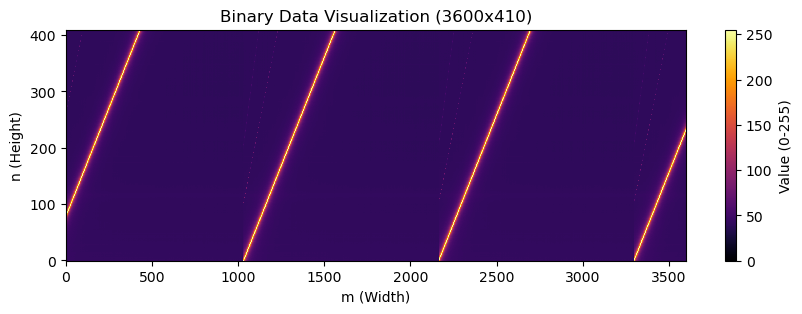

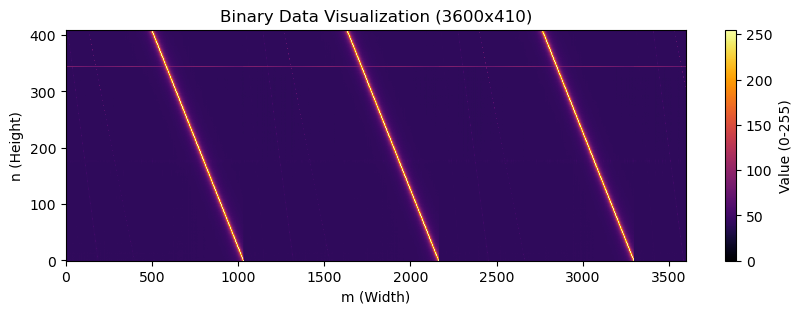

In [39]:
# 画像のサイズ定義 
num_rows = 3600     # n (縦)
num_cols = 410   # m (横)
test_filename = "/Volumes/Untitled/drs4/data/rh_low.bin"
plot_binary_data(test_filename, num_rows, num_cols)
test_filename = "/Volumes/Untitled/drs4/data/lh_low.bin"
plot_binary_data(test_filename, num_rows, num_cols)

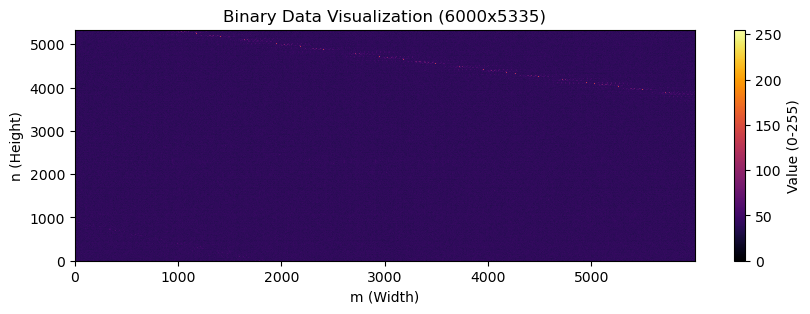

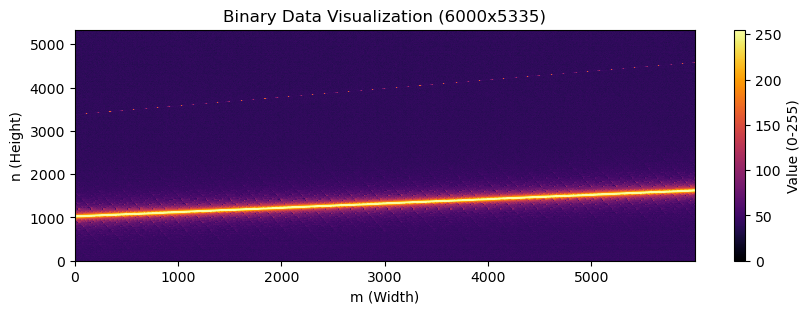

In [40]:
# 画像のサイズ定義 
num_rows = 6000     # n (縦)
num_cols = 5335   # m (横)
test_filename = "/Volumes/Untitled/drs4/data/lh_high_0000.bin"
plot_binary_data(test_filename, num_rows, num_cols)
test_filename = "/Volumes/Untitled/drs4/data/rh_high_0000.bin"
plot_binary_data(test_filename, num_rows, num_cols)